## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
M = 1.0
w_0 = 1.0          # Natural frequency (rad/s)
w_p = 2*w_0      # Driving frequency (rad/s), near 2*w_0 for w_p resonance
period = 2*jnp.pi/w_0
F_p = 0.03      # Amplitude of the w_p driving
Qual = 1000.0
GAMMA = w_0/(2*Qual)
gamma = .005          # Nonlinearity coefficient (Duffing term)

k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .5             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 10000# Start time
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
x0 = 1.0               # Initial displacement
v0 = 0.0               # Initial velocity
y0_x = jnp.array([x0, v0])


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(t,Q, P):
    dw = w_p/2 - w_0
    return 3*gamma/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(4*M*w_p) * (P**2 - Q**2)


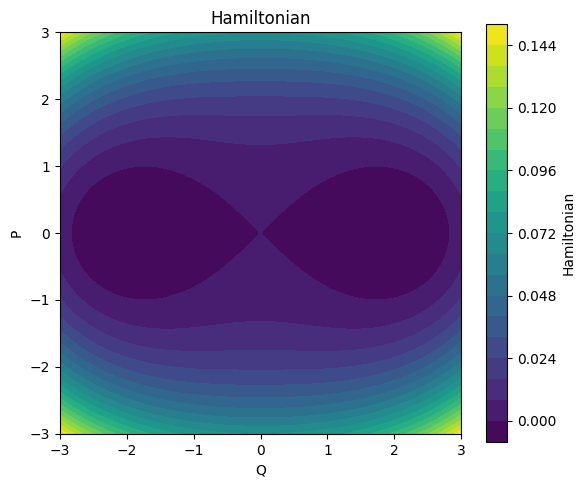

In [4]:
# Plot the Hamiltonian
Q_range = jnp.linspace(-2, 2, 100)*1.5
P_range = jnp.linspace(-2, 2, 100)*1.5
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian(0.,qi, pi))(q, p))(Q_mesh, P_mesh)

plt.figure(figsize=(6, 5))  # Adjusted size for single plot

# Create contour plot
contour = plt.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour, label='Hamiltonian')
plt.gca().set_aspect('equal')
plt.xlabel('Q')
plt.ylabel('P')
plt.title('Hamiltonian')

plt.tight_layout()
plt.show()

In [5]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    x, v = state
    dxdt = v
    dvdt =  -w_0/Qual * v -  (w_0**2 -F_p/M * jnp.cos(w_p * t)) * x - gamma * x**3 
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    noise_strength =  jnp.sqrt(4*GAMMA*k_B * T/M)  
    noise_matrix = jnp.zeros((2, 2))
    noise_matrix = noise_matrix.at[1, 1].set(noise_strength)
    return noise_matrix

In [6]:
w_shape = (2,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
saveat = diffrax.SaveAt(ts=ts_dim)


# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000,
    # stepsize_controller=PIDController(rtol=rtol, atol=atol),
)
sde_samples_x = solution_x.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

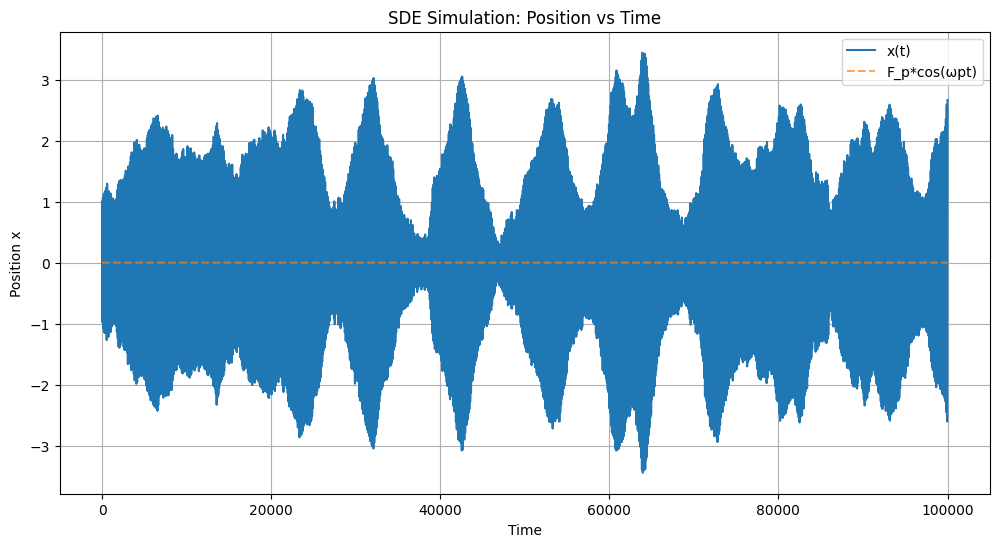

In [7]:
plt.figure(figsize=(12,  6))
plt.plot(sde_samples_x[:, 0], label='x(t)')
plt.plot(4 * 1e-8 * jnp.cos(w_0 * ts_dim), '--', label='F_p*cos(ωpt)', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
# # Amplitude Equations SDEs for RWA
def drift_QP_fn(t, state, args):
    """
    Drift function 
    """
    Q, P = state
        
    H = lambda _Q, _P: Hamiltonian(t,_Q, _P)
    
    dQdt =  jax.grad(H, 1)(Q, P) - w_0/(2*Qual)*Q
    dPdt = -jax.grad(H, 0)(Q, P) - w_0/(2*Qual)*P
    
    # Drift terms
    return jnp.array([dQdt, dPdt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations.
    Returns a 2x2 matrix where diagonal terms represent independent noise for Q and P.
    """
    noise_strength_QP =  jnp.sqrt(2*GAMMA*k_B * T/(M*w_0**2))  
    return noise_strength_QP * jnp.eye(2) 



In [9]:
w_shape = (2,)  # state is (Q, P)
brownian_motion_QP = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

y0_QP = jnp.array([x0, 0.0])

terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion_QP))

saveat = diffrax.SaveAt(ts=ts_dim)

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000000,
    # stepsize_controller=diffrax.PIDController(rtol=rtol, atol=atol),
)
sde_samples_QP = solution_QP.ys



100.00%|##########| [01:10<00:00,  1.42%/s]


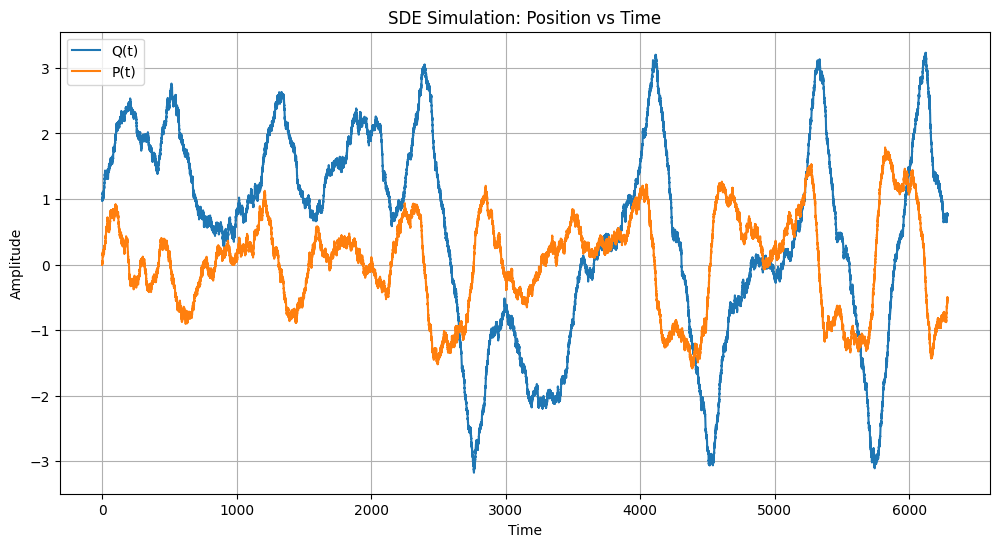

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(ts_dim, sde_samples_QP[:, 0], label='Q(t)')
plt.plot(ts_dim, sde_samples_QP[:, 1], label='P(t)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

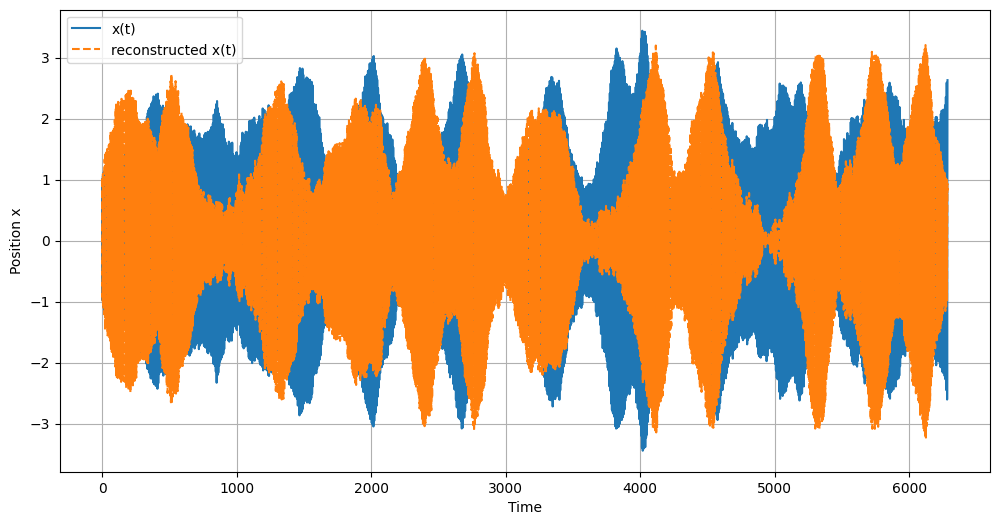

In [11]:
def reconstruct_x(t, Q, P):
    """
    Reconstruct x(t) from Q(t) and P(t).
    """
    return Q * jnp.cos(w_0 * t) + P * jnp.sin(w_0 * t)

id_start = 0
id_end = -1


x_direct = sde_samples_x[id_start:id_end, 0]
x_reconstructed = reconstruct_x(ts_dim[id_start:id_end], sde_samples_QP[id_start:id_end, 0], sde_samples_QP[id_start:id_end  , 1])

plt.figure(figsize=(12, 6))
plt.plot(ts_dim[id_start:id_end],x_direct, label='x(t)')
plt.plot(ts_dim[id_start:id_end],x_reconstructed, '--', label='reconstructed x(t)')

plt.xlabel('Time')
plt.ylabel('Position x')
# plt.title(f'Reconstructed x(t) from Q(t) and P(t) - L2 Loss: {l2_diff:.6f}')
plt.grid(True)
plt.legend()
plt.show()

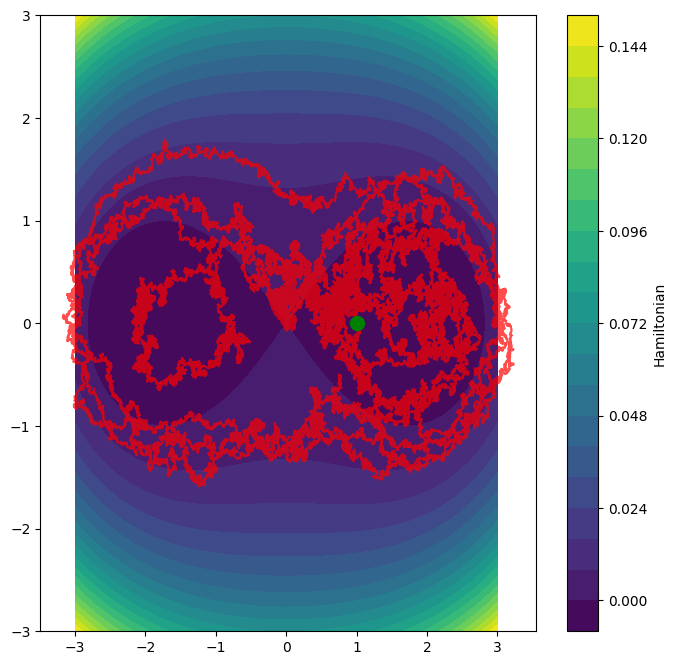

In [12]:
# Create contour plot with fixed square aspect ratio
plt.figure(figsize=(8, 8))  # Make figure square

# Create contour plot
plt.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(label='Hamiltonian')

# Add trajectory
plt.plot(sde_samples_QP[:, 0], sde_samples_QP[:, 1], 'r-', label='Trajectory', alpha=0.7)
plt.plot(sde_samples_QP[0, 0], sde_samples_QP[0, 1], 'go', label='Start', markersize=10)
plt.show()


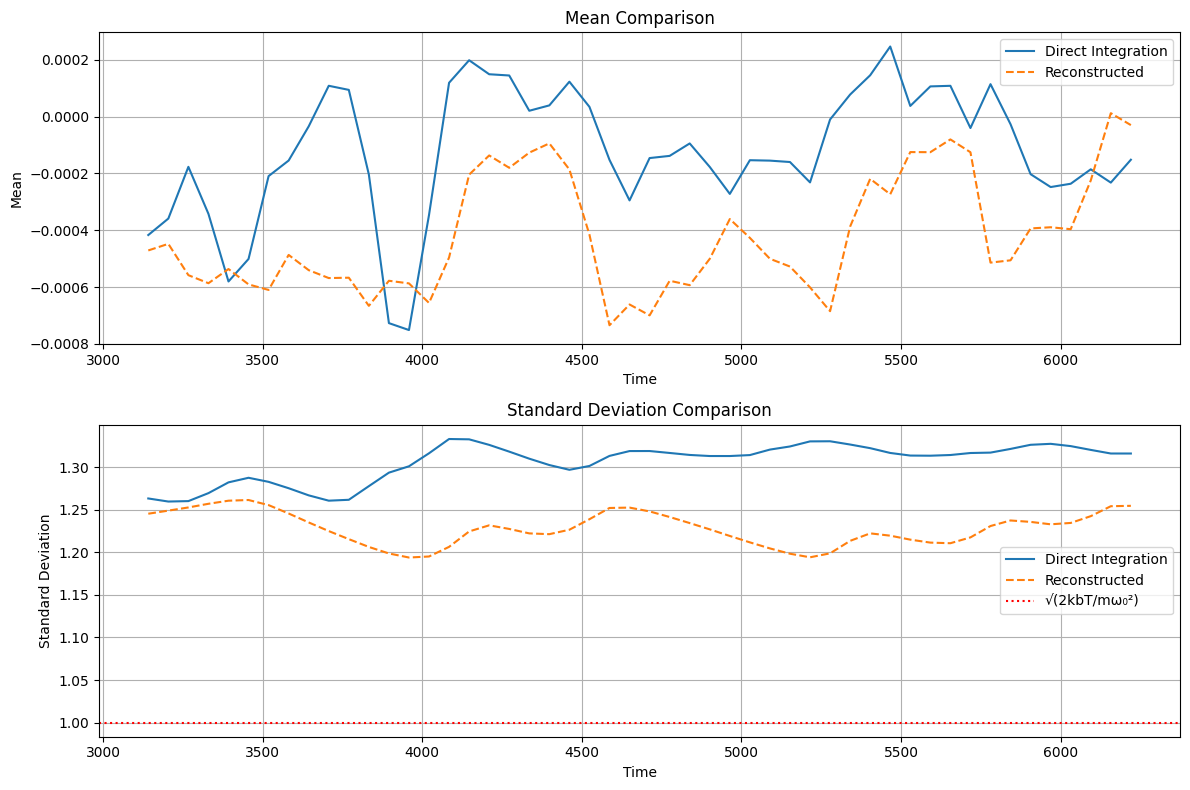

In [13]:
# After the reconstruction plot, add:

mean_direct = []
std_direct = []
mean_reconstructed = []
std_reconstructed = []
step = 1000 
for i in range(len(ts_dim)//2, len(ts_dim), step):

    # Compute statistics
    mean_direct.append(jnp.mean(x_direct[:i]))
    std_direct.append(jnp.std(x_direct[:i]))
    mean_reconstructed.append(jnp.mean(x_reconstructed[:i]))
    std_reconstructed.append(jnp.std(x_reconstructed[:i]))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot means
ax1.plot(ts_dim[len(ts_dim)//2::step], mean_direct, label='Direct Integration')
ax1.plot(ts_dim[len(ts_dim)//2::step], mean_reconstructed, '--', label='Reconstructed')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mean')
ax1.set_title('Mean Comparison')
ax1.grid(True)
ax1.legend()

# Plot standard deviations
ax2.plot(ts_dim[len(ts_dim)//2::step], std_direct, label='Direct Integration')
ax2.plot(ts_dim[len(ts_dim)//2::step], std_reconstructed, '--', label='Reconstructed')
# Add horizontal line at 2kbT
ax2.axhline(y=jnp.sqrt(k_B*T/M), color='r', linestyle=':', label='√(2kbT/mω₀²)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Standard Deviation')
ax2.set_title('Standard Deviation Comparison')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

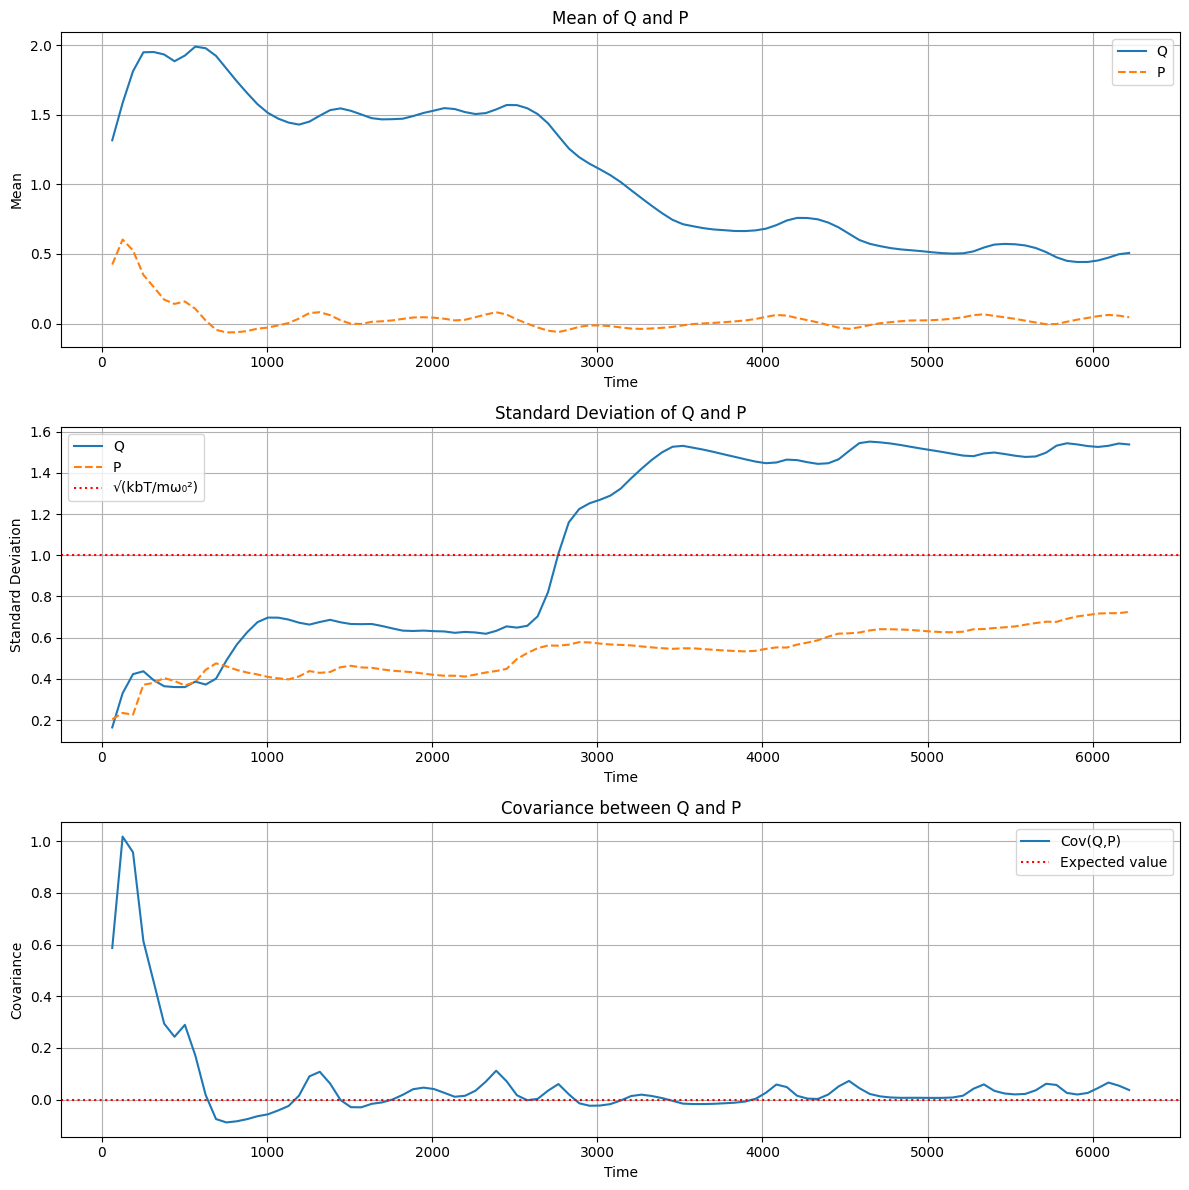

In [14]:
# Compute statistics for Q and P
mean_Q = []
mean_P = []
std_Q = []
std_P = []
cov_QP = []
step = 1000

for i in range(0, len(ts_dim), step):
    # Compute means and standard deviations
    mean_Q.append(jnp.mean(sde_samples_QP[:i, 0]))
    mean_P.append(jnp.mean(sde_samples_QP[:i, 1]))
    std_Q.append(jnp.std(sde_samples_QP[:i, 0]))
    std_P.append(jnp.std(sde_samples_QP[:i, 1]))
    # Compute covariance
    cov_QP.append(jnp.mean(sde_samples_QP[:i, 0] * sde_samples_QP[:i, 1]))

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Plot means
ax1.plot(ts_dim[::step], mean_Q, label='Q')
ax1.plot(ts_dim[::step], mean_P, '--', label='P')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mean')
ax1.set_title('Mean of Q and P')
ax1.grid(True)
ax1.legend()

# Plot standard deviations
ax2.plot(ts_dim[::step], std_Q, label='Q')
ax2.plot(ts_dim[::step], std_P, '--', label='P')
# Add horizontal line at theoretical value
theoretical_std = jnp.sqrt(k_B*T/(M*w_0**2))
ax2.axhline(y=theoretical_std, color='r', linestyle=':', label='√(kbT/mω₀²)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Standard Deviation')
ax2.set_title('Standard Deviation of Q and P')
ax2.grid(True)
ax2.legend()

# Plot covariance
ax3.plot(ts_dim[::step], cov_QP, label='Cov(Q,P)')
ax3.axhline(y=0, color='r', linestyle=':', label='Expected value')
ax3.set_xlabel('Time')
ax3.set_ylabel('Covariance')
ax3.set_title('Covariance between Q and P')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()